# Demo E: Quantization

**Workshop Part 4** | LLM Inference at Scale | AI Engineering World's Fair 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/demos/demo_e_quantization_batching.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/demos/demo_e_quantization_batching.ipynb)
[![Workshop Link](https://img.shields.io/badge/Workshop-link-green)](https://molab.marimo.io/notebooks/nb_RgEKvqccgCJY5xvPUJeaFm)

**Goal:** Prove quantization optimizations with real measurements:
Load Mistral-7B in FP16 vs INT4, measure memory + throughput

**Hardware requirements:**
- Molab GPU (RTX Pro 6000, 96 GB) or any CUDA GPU with >= 24 GB

**AWS alternative:** If Molab GPU is unavailable, run on SageMaker ml.g5.xlarge (A10G 24GB).
Record the output and paste into the cells as pre-computed results.

In [1]:
# Install dependencies
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps',
    'openai', 'matplotlib>=3.9', 'narwhals', 'scikit-learn>=1.5', 'bitsandbytes', 'accelerate'])


0

## Experiment 1: Weight Quantization

We load the same model (Mistral-7B) at three precisions and measure:
- GPU memory consumed
- Inference throughput (tokens/sec)
- Quality (perplexity on a sample, to show it barely changes)

**Theory:** Fewer bits per parameter = less memory = more users on same GPU.
The question is: how much quality do we lose?

In [3]:
import torch
import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# === PARAMETERS ===
MODEL_ID = 'mistralai/Mistral-7B-v0.1'  # Non-gated model
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_OUTPUT_TOKENS = 64  # Tokens to generate for throughput measurement
PROMPT = 'Explain the concept of gradient descent in machine learning:'

# Store results for each precision
quant_results = {}  # {precision: {memory_gb, throughput_tok_s, load_time_s}}

print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA L4
VRAM: 23.7 GB


### Load 1: FP16 (Baseline)

Standard half-precision. 7.24B params x 2 bytes = ~14.5 GB.

In [4]:
def measure_model(model, tokenizer, label):
    """Measure memory usage and throughput for a loaded model."""
    # Memory measurement
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
        mem_gb = torch.cuda.memory_allocated() / 1e9
    else:
        mem_gb = 0.0

    # Tokenize prompt
    inputs = tokenizer(PROMPT, return_tensors='pt').to(model.device)

    # Warm-up run
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=1)

    # Throughput measurement
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=N_OUTPUT_TOKENS, do_sample=False)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    n_gen = out.shape[1] - inputs['input_ids'].shape[1]  # Actual tokens generated
    throughput = n_gen / elapsed  # Tokens per second

    print(f'  Memory: {mem_gb:.2f} GB')
    print(f'  Throughput: {throughput:.1f} tok/s')
    return {'memory_gb': mem_gb, 'throughput_tok_s': throughput}

In [5]:
# --- FP16 ---
print('Loading Mistral-7B in FP16...')
t0_load_fp16 = time.perf_counter()
model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map='auto', token=False
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=False)
load_time_fp16 = time.perf_counter() - t0_load_fp16

print(f'  Load time: {load_time_fp16:.1f}s')
quant_results['FP16'] = measure_model(model_fp16, tokenizer, 'FP16')
quant_results['FP16']['load_time_s'] = load_time_fp16

# Free memory
del model_fp16
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading Mistral-7B in FP16...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Load time: 22.7s


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Memory: 14.48 GB
  Throughput: 16.5 tok/s


### Load 2: INT8 (2x compression)

8-bit quantization via bitsandbytes. Each parameter stored in 1 byte instead of 2.
Expected: ~7.2 GB memory, minimal quality loss.

In [7]:
# --- INT8 ---
print('Loading Mistral-7B in INT8...')
quant_config_8bit = BitsAndBytesConfig(load_in_8bit=True)  # 8-bit quantization config

t0_load_int8 = time.perf_counter()
model_int8 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=quant_config_8bit, device_map='auto', token=False
)
load_time_int8 = time.perf_counter() - t0_load_int8

print(f'  Load time: {load_time_int8:.1f}s')
quant_results['INT8'] = measure_model(model_int8, tokenizer, 'INT8')
quant_results['INT8']['load_time_s'] = load_time_int8

# Free memory
del model_int8
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

Loading Mistral-7B in INT8...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Load time: 31.5s


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Memory: 9.80 GB
  Throughput: 4.2 tok/s


### Load 3: INT4 (4x compression)

4-bit quantization with NF4 (Normal Float 4). Each parameter in 0.5 bytes.
Expected: ~3.6 GB memory. Some quality loss on reasoning tasks.

In [9]:
# --- INT4 (NF4) ---
print('Loading Mistral-7B in INT4 (NF4)...')
quant_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',  # NormalFloat4 quantization
    bnb_4bit_compute_dtype=torch.float16  # Compute in FP16 for speed
)

t0_load_int4 = time.perf_counter()
model_int4 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=quant_config_4bit, device_map='auto', token=False
)
load_time_int4 = time.perf_counter() - t0_load_int4

print(f'  Load time: {load_time_int4:.1f}s')
quant_results['INT4'] = measure_model(model_int4, tokenizer, 'INT4')
quant_results['INT4']['load_time_s'] = load_time_int4

# Free memory
del model_int4
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

Loading Mistral-7B in INT4 (NF4)...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Load time: 5.5s


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Memory: 10.43 GB
  Throughput: 11.7 tok/s


### Quantization Results

Side-by-side comparison: memory, throughput, and implied max users.

Precision   Memory (GB)   Throughput Max Users (80GB)
-------------------------------------------------------
FP16            14.48       16.5 tok/s          214
INT8             9.80        4.2 tok/s          231
INT4            10.43       11.7 tok/s          229


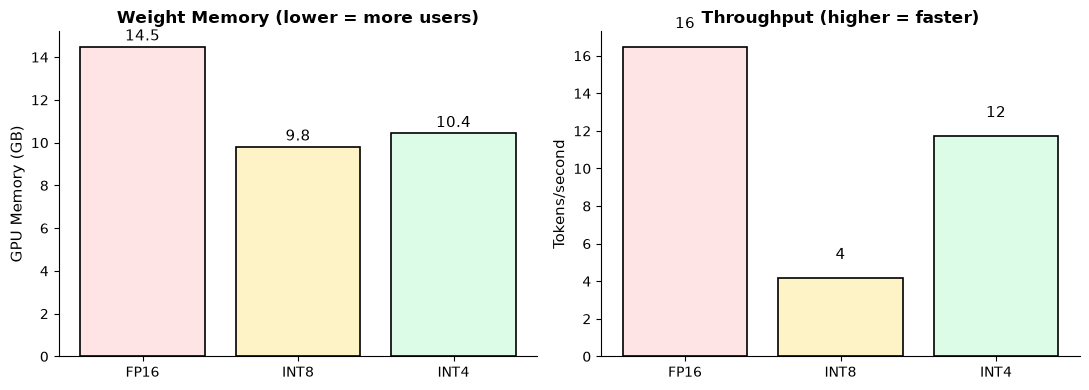


--- KEY INSIGHT ---
INT4 uses 1.4x less memory than FP16.
On an A100-80, that means 229 users instead of 214.


In [10]:
import matplotlib.pyplot as plt

# Print summary table
print(f'{"Precision":<10} {"Memory (GB)":>12} {"Throughput":>12} {"Max Users (80GB)":>16}')
print('-' * 55)
for prec, data in quant_results.items():
    # Max users: (80 - weight_mem - 8 overhead) / (0.131 KB/tok * 2048 ctx) per user
    kv_per_user_gb = 0.000131 * 2048  # 131 KB/tok * 2048 tokens
    available_gb = 80 - data['memory_gb'] - 8  # A100-80 minus weights minus overhead
    max_users = int(available_gb / kv_per_user_gb) if available_gb > 0 else 0
    print(f'{prec:<10} {data["memory_gb"]:>10.2f} {data["throughput_tok_s"]:>10.1f} tok/s {max_users:>12}')

# --- Comparison chart ---
fig_quant, (ax_mem, ax_tp) = plt.subplots(1, 2, figsize=(11, 4))

precisions = list(quant_results.keys())
memories = [quant_results[p]['memory_gb'] for p in precisions]
throughputs = [quant_results[p]['throughput_tok_s'] for p in precisions]
colors = ['#ffe4e6', '#fef3c7', '#dcfce7']  # rose -> amber -> green (better)

# Memory bars
bars_mem = ax_mem.bar(precisions, memories, color=colors, edgecolor='#000', linewidth=1.2)
ax_mem.set_ylabel('GPU Memory (GB)', fontsize=11)
ax_mem.set_title('Weight Memory (lower = more users)', fontsize=12, fontweight='bold')
for bar, val in zip(bars_mem, memories):
    ax_mem.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}',
               ha='center', fontsize=11)
ax_mem.spines['top'].set_visible(False)
ax_mem.spines['right'].set_visible(False)

# Throughput bars
bars_tp = ax_tp.bar(precisions, throughputs, color=colors, edgecolor='#000', linewidth=1.2)
ax_tp.set_ylabel('Tokens/second', fontsize=11)
ax_tp.set_title('Throughput (higher = faster)', fontsize=12, fontweight='bold')
for bar, val in zip(bars_tp, throughputs):
    ax_tp.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}',
               ha='center', fontsize=11)
ax_tp.spines['top'].set_visible(False)
ax_tp.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\n--- KEY INSIGHT ---')
print(f'INT4 uses {memories[0]/memories[2]:.1f}x less memory than FP16.')
print(f'On an A100-80, that means {int((80-memories[2]-8)/0.268)} users instead of {int((80-memories[0]-8)/0.268)}.')

## Summary: Three Optimizations

| Optimization | What It Does | Speedup | Tradeoff |
|-------------|-------------|---------|----------|
| **Quantization** | Fewer bits per weight | 2-4x more users | Minor quality loss at INT4 |

**Key insight:** These are orthogonal. You can stack all three:
- INT4 weights (4x less memory)

In practice, you get 10-20x improvement. The engines (Part 5) implement all of these.